# 📊 FIAP - Feature Engineering
## Pré-processamento de Dados: Outliers e Dados Duplicados

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 1 - Fundamentos e Pré-processamento
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais para identificação e tratamento de:
- **Outliers:** Valores atípicos que podem comprometer análises estatísticas
- **Dados Duplicados:** Registros redundantes que distorcem resultados
- **Visualizações:** Técnicas gráficas para identificação de anomalias
- **Comparação de Métodos:** Avaliação do impacto de diferentes abordagens de tratamento

---

### 📊 **Dataset Utilizado**
**House Prices Dataset** - Dados de preços de imóveis residenciais
- **Fonte:** Kaggle - House Prices: Advanced Regression Techniques (adaptado)
- **Registros:** Conjunto de propriedades residenciais
- **Features:** 13 características dos imóveis + 1 variável target (preço)
- **Objetivo:** Análise e tratamento de anomalias nos dados imobiliários

---

### 🔧 **Principais Técnicas Aplicadas**
1. **Detecção de Outliers:**
   - Método do Intervalo Interquartil (IQR)
   - Visualizações: boxplots, scatter plots

2. **Tratamento de Outliers:**
   - Remoção de valores extremos
   - Transformação logarítmica
   - Winsorização (capping)

3. **Dados Duplicados:**
   - Identificação de registros duplicados
   - Estratégias de remoção
   - Validação da qualidade dos dados

4. **Validação:**
   - Comparação de modelos antes/depois do tratamento
   - Métricas de performance e visualizações

---

# 1. Introdução

## Lidando com Outliers e Dados Duplicados

Este notebook aborda técnicas para lidar com outliers e dados duplicados em um dataset. Utilizaremos o dataset "House Prices - Advanced Regression Techniques" do Kaggle como exemplo.

# 2. Carregamento e Exploração Inicial do Dataset

## 2.1 Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para análise de outliers e dados duplicados, organizadas por categoria de uso.

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas (boxplots, heatmaps)

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler    # Normalização de dados (escala 0-1)
from sklearn.impute import SimpleImputer          # Imputação de valores faltantes
from sklearn.linear_model import LinearRegression # Modelo de regressão 
from sklearn.tree import DecisionTreeRegressor   # Modelo de árvore de decisão para regressão
from sklearn.model_selection import train_test_split  # Divisão de dados treino/teste
from sklearn.metrics import mean_absolute_error, r2_score  # Métricas de avaliação

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configurar exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Configurar warnings
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade dos resultados
np.random.seed(42)

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


## 2.2 Carregamento do Dataset

Dataset "House Prices"
Este dataset, originalmente retirado de Kaggle - House Prices Dataset, foi editado para a finalidade deste notebook. Ele contém informações sobre preços de imóveis e diversas características associadas a cada propriedade. O objetivo é analisar e manipular os dados para entender como as características dos imóveis influenciam seus preços.


- Principais Características do Dataset:
    - LotArea: Área do lote (em pés quadrados).
    - OverallQual: Qualidade geral da casa (em uma escala de 1 a 10).
    - YearBuilt: Ano de construção da casa.
    - TotalBsmtSF: Área total do porão (em pés quadrados).
    - GrLivArea: Área de vida acima do porão (em pés quadrados).
    - GarageCars: Número de carros que a garagem pode acomodar.
    - GarageArea: Área da garagem (em pés quadrados).
    - FullBath: Número de banheiros completos.
    - HalfBath: Número de banheiros meio.
    - BedroomAbvGr: Número de quartos acima do nível do chão.
    - Fireplaces: Número de lareiras.
    - PoolArea: Área da piscina (em pés quadrados).
    - Fence: Tipo de cerca (se aplicável).
    - Preço: SalePrice: Preço final do imóvel (em dólares).

- Importância das Variáveis:
    - LotArea: A área do lote pode impactar o preço, pois imóveis maiores geralmente têm um valor mais alto.
    - OverallQual: A qualidade geral da casa é um forte indicador de preço, com casas de maior qualidade tendo preços mais altos.
    - YearBuilt: O ano de construção pode influenciar o preço, com imóveis mais novos geralmente sendo mais caros.
    - TotalBsmtSF: A área total do porão pode adicionar valor ao imóvel, especialmente se for utilizável e bem acabado.
    - GrLivArea: A área de vida acima do porão é uma medida importante da capacidade e tamanho da casa, afetando o preço.
    - GarageCars: O número de carros que a garagem pode acomodar pode impactar o preço, especialmente em áreas onde a garagem é valorizada.
    - GarageArea: A área da garagem também pode influenciar o preço.
    - FullBath e HalfBath: O número de banheiros completos e meio pode afetar o preço, pois imóveis com mais banheiros são geralmente mais valiosos.
    - BedroomAbvGr: O número de quartos acima do nível do chão é uma característica importante para compradores e pode influenciar o preço.
    - Fireplaces: A presença de lareiras pode adicionar valor, especialmente em climas frios.
    - PoolArea: A presença de uma piscina pode aumentar o preço, mas seu impacto pode variar com base na localização e demanda local.
    - Fence: A presença de uma cerca pode adicionar valor, dependendo das preferências dos compradores.

- Fonte do Dataset:

    - O dataset está originalmente disponível em: [Kaggle - House Prices Dataset](https://www.kaggle.com/datasets/lespin/house-prices-dataset)

In [2]:
df = pd.read_csv('datasets/house_prices.csv')

## 2.3 Visualização Inicial dos Dados

In [3]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


## 2.4 Informações do Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3210 entries, 0 to 3209
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     3210 non-null   int64  
 1   MSZoning       3205 non-null   object 
 2   LotFrontage    2673 non-null   float64
 3   LotArea        3210 non-null   int64  
 4   Street         3210 non-null   object 
 5   Alley          229 non-null    object 
 6   LotShape       3210 non-null   object 
 7   LandContour    3210 non-null   object 
 8   Utilities      3208 non-null   object 
 9   LotConfig      3210 non-null   object 
 10  LandSlope      3210 non-null   object 
 11  Neighborhood   3210 non-null   object 
 12  Condition1     3210 non-null   object 
 13  Condition2     3210 non-null   object 
 14  BldgType       3210 non-null   object 
 15  HouseStyle     3210 non-null   object 
 16  OverallQual    3210 non-null   int64  
 17  OverallCond    3210 non-null   int64  
 18  YearBuil

## 2.5 Estatísticas Descritivas

In [5]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,3210.000,2673.000,3210.000,3210.000,3210.000,3210.000,3210.000,3186.000,3209.000,3209.000,3209.000,3209.000,3210.000,3210.000,3210.000,3210.000,3208.000,3208.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3035.000,3209.000,3209.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,3210.000,1595.000
mean,57.227,69.345,10151.472,6.086,5.564,1971.131,1984.222,102.518,443.111,48.561,560.555,1052.227,1161.302,337.783,4.827,1503.913,0.431,0.059,1.571,0.381,2.863,1.046,6.449,0.598,1977.864,1.766,473.277,93.931,48.030,23.069,2.496,16.363,2.119,49.679,6.195,2007.798,181484.144
std,42.585,23.388,7715.994,1.409,1.119,30.367,20.913,179.281,457.325,168.218,438.076,439.720,393.246,430.000,46.338,507.226,0.528,0.241,0.556,0.503,0.830,0.216,1.569,0.651,25.749,0.763,216.520,127.379,68.937,63.684,24.602,56.913,34.248,553.698,2.717,1.312,79885.211
min,20.000,21.000,1300.000,1.000,1.000,1872.000,1950.000,0.000,0.000,0.000,0.000,0.000,334.000,0.000,0.000,334.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,1895.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,2006.000,34900.000
25%,20.000,59.000,7427.750,5.000,5.000,1953.000,1965.000,0.000,0.000,0.000,222.000,792.000,876.000,0.000,0.000,1131.000,0.000,0.000,1.000,0.000,2.000,1.000,5.000,0.000,1960.000,1.000,322.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.000,2007.000,129900.000
50%,50.000,68.000,9465.000,6.000,5.000,1973.000,1993.000,0.000,368.000,0.000,469.000,990.000,1086.000,0.000,0.000,1450.000,0.000,0.000,2.000,0.000,3.000,1.000,6.000,1.000,1979.000,2.000,480.000,0.000,26.000,0.000,0.000,0.000,0.000,0.000,6.000,2008.000,163900.000
75%,70.000,80.000,11613.000,7.000,6.000,2001.000,2004.000,165.000,736.000,0.000,801.000,1304.000,1390.000,702.000,0.000,1743.750,1.000,0.000,2.000,1.000,3.000,1.000,7.000,1.000,2002.000,2.000,576.000,168.000,70.000,0.000,0.000,0.000,0.000,0.000,8.000,2009.000,215000.000
max,190.000,313.000,215245.000,10.000,9.000,2010.000,2010.000,1600.000,5644.000,1526.000,2336.000,6110.000,5095.000,2065.000,1064.000,5642.000,3.000,2.000,4.000,2.000,8.000,3.000,15.000,4.000,2207.000,5.000,1488.000,1424.000,742.000,1012.000,508.000,576.000,800.000,17000.000,12.000,2010.000,755000.000


## 2.6 Selecionando Variáveis Numéricas

In [6]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

In [7]:
numeric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3210 entries, 0 to 3209
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     3210 non-null   int64  
 1   LotFrontage    2673 non-null   float64
 2   LotArea        3210 non-null   int64  
 3   OverallQual    3210 non-null   int64  
 4   OverallCond    3210 non-null   int64  
 5   YearBuilt      3210 non-null   int64  
 6   YearRemodAdd   3210 non-null   int64  
 7   MasVnrArea     3186 non-null   float64
 8   BsmtFinSF1     3209 non-null   float64
 9   BsmtFinSF2     3209 non-null   float64
 10  BsmtUnfSF      3209 non-null   float64
 11  TotalBsmtSF    3209 non-null   float64
 12  1stFlrSF       3210 non-null   int64  
 13  2ndFlrSF       3210 non-null   int64  
 14  LowQualFinSF   3210 non-null   int64  
 15  GrLivArea      3210 non-null   int64  
 16  BsmtFullBath   3208 non-null   float64
 17  BsmtHalfBath   3208 non-null   float64
 18  FullBath

# 3. Identificação e Tratamento de Outliers

## 3.1 Identificação de Outliers com Boxplot

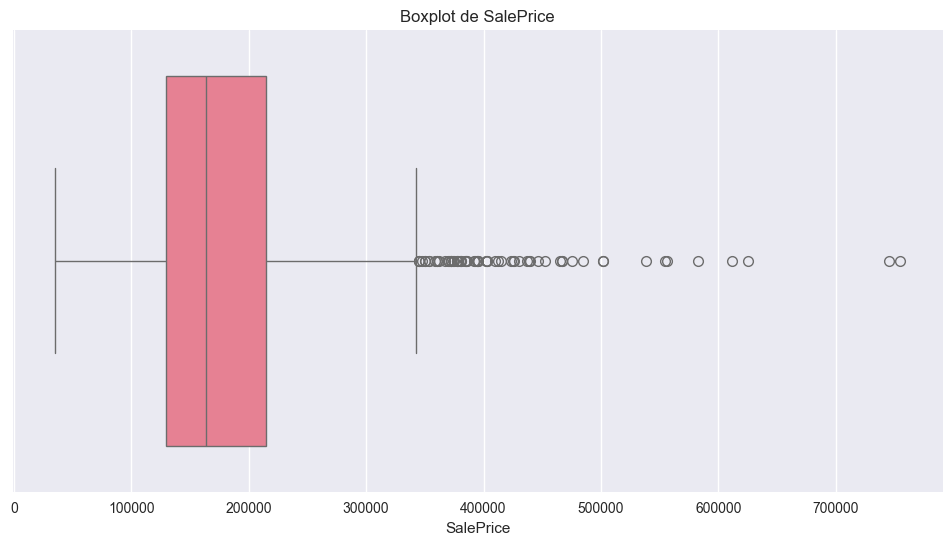

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df, x='SalePrice')
plt.title('Boxplot de SalePrice')
plt.show()

## 3.2 Remoção de Outliers

In [9]:
# Definindo o limite superior como o percentil 90
upper_limit = numeric_df['SalePrice'].quantile(0.90)
numeric_df_treated = numeric_df[numeric_df['SalePrice'] < upper_limit]

## 3.3 Visualização após Remoção de Outliers

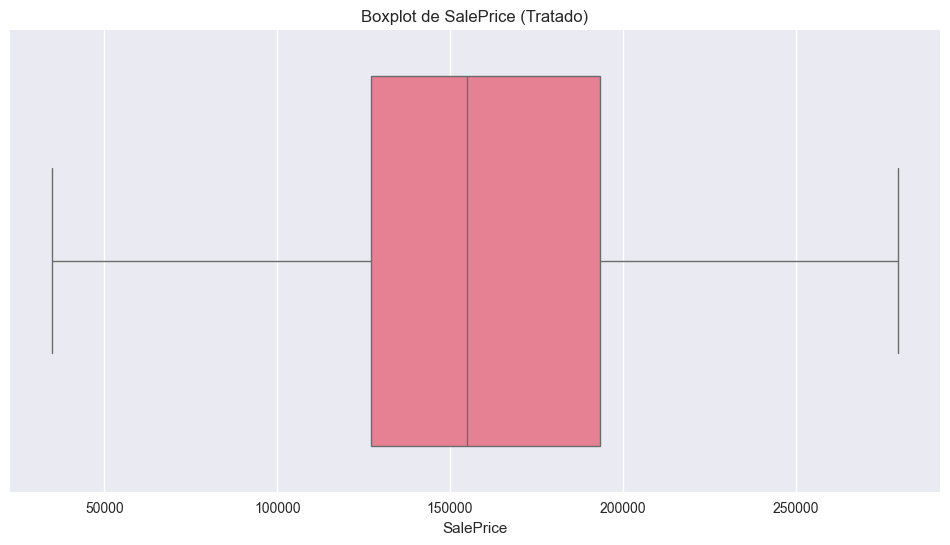

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df_treated, x='SalePrice')
plt.title('Boxplot de SalePrice (Tratado)')
plt.show()

# 4. Identificação e Remoção de Dados Duplicados

## 4.1 Verificação de Duplicatas

In [11]:
duplicates = numeric_df_treated.duplicated()
num_duplicates = duplicates.sum()
print(f"Número de registros duplicados: {num_duplicates}")

Número de registros duplicados: 117


## 4.2 Remoção de Duplicatas

In [12]:
numeric_df_treated_wo_duplicates = numeric_df_treated.drop_duplicates()

## 4.3 Verificação após Remoção

In [13]:
duplicates_check = numeric_df_treated_wo_duplicates.duplicated()
num_duplicates_check = duplicates_check.sum()
print(f"Número de registros duplicados após remoção: {num_duplicates_check}")

Número de registros duplicados após remoção: 0


# 5. Imputação de Dados Faltantes

## 5.1 Imputação dos valores faltantes com a média da coluna

In [14]:
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(numeric_df_treated_wo_duplicates), columns=numeric_df_treated_wo_duplicates.columns)

# 6. Normalização dos Dados

In [ ]:
# Fazer uma cópia do dataset
df_scaled = df_imputed.copy()

# Separar a coluna target
target = df_scaled['SalePrice']
features = df_scaled.drop(columns=['SalePrice'])

# Escalar as features
scaler = MinMaxScaler( feature_range=(-1, 1))  # Normalização para o intervalo [0, 1]
#scaler = StandardScaler(with_mean=True, with_std=True)
scaled_features = scaler.fit_transform(features)

# Criar um DataFrame com as features escalonadas
df_scaled_features = pd.DataFrame(scaled_features, columns=features.columns)

# Adicionar a coluna target de volta ao DataFrame
df_scaled_features = pd.concat([df_scaled_features, target.reset_index(drop=True)], axis=1)

df_scaled_features.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,-0.529,-0.699,-0.912,0.333,0.00,0.912,0.767,-0.755,-0.750,-1.0,-0.853,-0.720,-0.760,0.060,-1.0,-0.482,-0.333,-1.0,0.333,0.0,-0.25,-0.333,0.000,-1.000,0.873,0.0,-0.227,-1.000,-0.777,-1.000,-1.0,-1.0,-1.0,-1.0,-0.818,0.0,208500.0
1,-1.000,-0.596,-0.898,0.111,0.75,0.518,-0.133,-1.000,-0.653,-1.0,-0.722,-0.587,-0.574,-1.000,-1.0,-0.650,-1.000,0.0,0.333,-1.0,-0.25,-0.333,-0.333,-0.333,0.382,0.0,-0.351,-0.190,-1.000,-1.000,-1.0,-1.0,-1.0,-1.0,-0.273,-0.5,181500.0
2,-0.529,-0.678,-0.878,0.333,0.00,0.883,0.733,-0.797,-0.828,-1.0,-0.575,-0.699,-0.731,0.075,-1.0,-0.453,-0.333,-1.0,0.333,0.0,-0.25,-0.333,-0.333,-0.333,0.836,0.0,-0.142,-1.000,-0.846,-1.000,-1.0,-1.0,-1.0,-1.0,0.455,0.0,223500.0
3,-0.412,-0.733,-0.899,0.333,0.00,-0.372,-0.333,-1.000,-0.923,-1.0,-0.471,-0.753,-0.712,-0.061,-1.0,-0.479,-0.333,-1.0,-0.333,-1.0,-0.25,-0.333,-0.167,-0.333,0.782,0.5,-0.094,-1.000,-0.872,-0.014,-1.0,-1.0,-1.0,-1.0,-0.818,-1.0,140000.0
4,-0.529,-0.568,-0.841,0.556,0.00,0.869,0.667,-0.562,-0.768,-1.0,-0.520,-0.625,-0.628,0.307,-1.0,-0.298,-0.333,-1.0,0.333,0.0,0.00,-0.333,0.167,-0.333,0.818,0.5,0.179,-0.478,-0.693,-1.000,-1.0,-1.0,-1.0,-1.0,1.000,0.0,250000.0


# 7. Comparação dos Resultados de ML com Dados Brutos e Tratados

## 7.1 Preparação dos Dados

In [16]:
X_raw = df_imputed.drop('SalePrice', axis=1)
y_raw = df_imputed['SalePrice'].loc[X_raw.index]

X_treated = df_scaled_features.drop('SalePrice', axis=1)
y_treated = df_scaled_features['SalePrice'].loc[X_treated.index]

## 7.2 Divisão dos Dados em Treino e Teste

In [17]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
X_train_treated, X_test_treated, y_train_treated, y_test_treated = train_test_split(X_treated, y_treated, test_size=0.2, random_state=42)

# 7.3 Treinamento do Modelo com Dados Brutos

In [18]:
model_raw = LinearRegression()
#model_raw = DecisionTreeRegressor()
model_raw.fit(X_train_raw, y_train_raw)
predictions_raw = model_raw.predict(X_test_raw)

## 7.4 Treinamento do Modelo com Dados Tratados

In [19]:
model_treated = LinearRegression()
#model_treated = DecisionTreeRegressor()
model_treated.fit(X_train_treated, y_train_treated)
predictions_treated = model_treated.predict(X_test_treated)

## 7.5 Avaliação dos Resultados

In [20]:
# Exemplo de valores para mae_raw e mae_treated
mae_raw = mean_absolute_error(y_test_raw, predictions_raw)
mae_treated = mean_absolute_error(y_test_treated, predictions_treated)

# Calculando a diferença percentual
percentual_difference = ((mae_raw - mae_treated) / mae_raw) * 100

# Imprimindo os resultados
print(f"MAE com dados brutos: {mae_raw:.2f}")
print(f"MAE com dados tratados: {mae_treated:.2f}")
print(f"Diferença percentual: {percentual_difference:.2f}%")

MAE com dados brutos: 15847.15
MAE com dados tratados: 15847.50
Diferença percentual: -0.00%


In [21]:
# Exemplo de valores para y_test_raw, predictions_raw, y_test_treated e predictions_treated

# Calculando o R^2 para dados brutos e tratados
r2_raw = r2_score(y_test_raw, predictions_raw)
r2_treated = r2_score(y_test_treated, predictions_treated)

# Calculando a diferença percentual
percentual_difference = ((r2_raw - r2_treated) / r2_raw) * 100

# Imprimindo os resultados
print(f"R^2 com dados brutos: {r2_raw:.3f}")
print(f"R^2 com dados tratados: {r2_treated:.3f}")
print(f"Diferença percentual: {percentual_difference:.2f}%")

R^2 com dados brutos: 0.768
R^2 com dados tratados: 0.768
Diferença percentual: 0.00%


## 7.6 Visualização dos Resultados

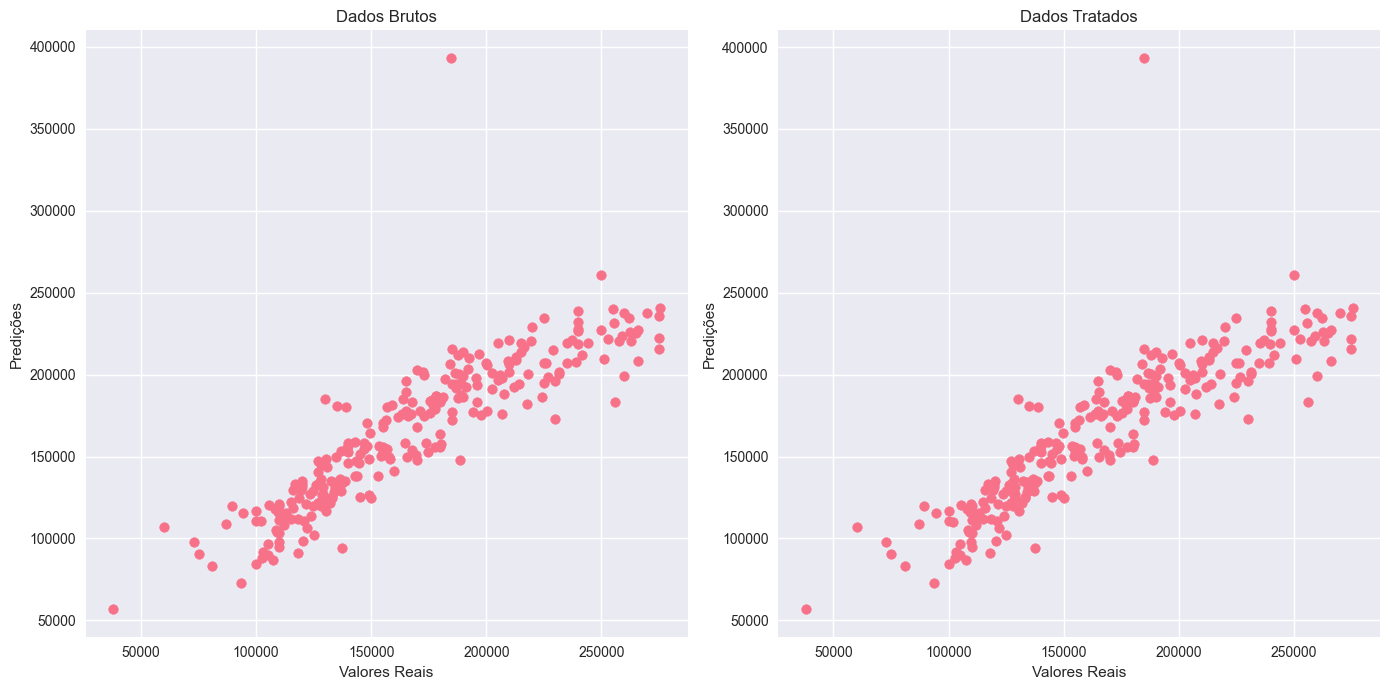

In [22]:
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.scatter(y_test_raw, predictions_raw)
plt.title('Dados Brutos')
plt.xlabel('Valores Reais')
plt.ylabel('Predições')

plt.subplot(1, 2, 2)
plt.scatter(y_test_treated, predictions_treated)
plt.title('Dados Tratados')
plt.xlabel('Valores Reais')
plt.ylabel('Predições')

plt.tight_layout()
plt.show()